This Mars Rover model complies with the assumption of markovianity by the fact that the actions taken by the rover at any given time step depends only on the current state of the rover.

## 1.2 
Expressing the problem as a Markov Process

Definition of a Markov Process:
A tuple <S, P> where S is a set of states and P is a transition probability matrix that defines the probabilities of transitioning from one state to another.

For our Mars Rover problem, the set of states S = {Explore, Pictures, Sample, Recharge, Malfunction}

The transition probability matrix P=
\[
P =
\begin{array}{c|ccccc}
 & Explore & Pictures & Sample & Recharge & Malfunction \\
\hline
Explore & 0.7 & 0.6 & 0.35 & 1.0 & 0.0 \\
Pictures & 0.1 & 0.0 & 0.0 & 0.0 & 0.0 \\
Sample & 0.1 & 0.4 & 0.3 & 0.0 & 0.0 \\
Recharge & 0.1 & 0.0 & 0.3 & 0.0 & 0.0 \\
Malfunction & 0.0 & 0.0 & 0.05 & 0.0 & 1.0
\end{array}
\]


## 1.3
When you are in the normal explore state, the rover has no possibility of malfunctioning.
When the rover malfunctions, it cannot transition back to any other state. e.g. the reachability to other states is compromised.

## 1.4
Probability of malfunctioning within the first 10 minutes is 0, as the rover cannot transition to the malfunction state from the explore state.

In the next 10 minutes, the only way it can reach the malfunction state is through the sample state. The probability of transitioning from explore to sample is 0.35, and from sample to malfunction is 0.05. Therefore, the probability of malfunctioning within the next 10 minutes is 0.35 * 0.05 = 0.0175 or 1.75%.

In the 10 minutes after that, we have more possible paths to malfunction. The rover can transition from explore to pictures, then to sample, and finally to malfunction. The probability of this path is 0.6 * 0.4 * 0.05 = 0.012 or 1.2%.
We also have the path from explore to sample to malfunction, which we already calculated as 0.0175 or 1.75%.
And the path from explore to sample to sample to malfunction, which is 0.35 * 0.3 * 0.05 = 0.00525 or 0.525%.
Adding these probabilities together, the total probability of malfunctioning within the next 30 minutes is 0.0175 + 0.012 + 0.00525 = 0.03475 or 3.475%.

## 1.5
If the probability of malfunctioning depends on the times the rover has been in the sample state, then the Markov property is violated. This is because the transition probabilities does not only depend on the current state but also on the past history of states.

## 1.6
The tic-tac-toe game can be modeled as a Markov Process as your next action only depends on the current state of the board.

## 1.7
You have 3 options for every square on the tic-tac-toe board: X, O and empty. Since there are 9 squares, the total number of states is 3^9 = 19683.


## Exercise 2

Expected reward for the first 10 minutes:
E[R | Explore] = 0.7 * 0 + 0.1 * 5 + 0.1 * 20 + 0.1 * 0 + 0 * (-100) = 2.5

Probability of negative reward within first 20 minutes:
P[Negative Reward | Explore] = P[Malfunction | Explore] = 0.0175 or 1.75%
This is because the only way to get a negative reward is to transition to the malfunction state, which we calculated in Exercise 1.4.

## 3. Markov Decision Processes

To model it as a Markov Decision Process, we need to define the set of actions A and the reward function R.
We have the same set of states S = {Explore, Pictures, Sample, Recharge, Malfunction}
The set of actions A = {Run program}
Probability transition matrix P is the same as defined in Exercise 1.2. because we ess


## Part 2

1. To model this as a MDP we need the to define the tuple <S, A, P, R, gamma> where S is the set of states, A is the set of actions, P is the transition probability matrix and R is the reward function. 
- S = {position}
- A = {straight, diagonal up, diagonal down}
- P is the transition probability matrix. But all transitions are deterministic, so the probability of transitioning to the next state is 1 for the action taken and 0 for all other actions.
- R is roughness of the terrain at the terrain the rover is currently on. More reward for terrain that the robot can move through faster.
- gamma is the discount factor.

In [19]:
# Policy evalutation algorithm
import numpy as np
import matplotlib.pyplot as plt
from mountain import Mountain_one

env = Mountain_one()
terrain = env.get_map()
n_rows, n_cols = terrain.shape  # should be (31, 100)
actions = env.actions           # ['upforward', 'forward', 'downforward']

print("shape:", terrain.shape)




shape: (31, 100)


In [20]:
import numpy as np
from mountain import Mountain_one

def policy_evaluation(env, policy, gamma=1.0, theta=1e-8, max_iters=10000):
    n_rows, n_cols = env.get_map().shape
    V = np.zeros((n_rows, n_cols), dtype=float)  # initialize v^(0)

    for k in range(max_iters):                    # for k = 1...T
        delta = 0.0
        V_old = V.copy()

        for i in range(n_rows):                   # for each state s
            for j in range(n_cols):
                s = (i, j)

                if j == n_cols - 1:               # terminal-like last column
                    V[i, j] = 0.0
                    continue

                a = policy[i, j]                  # deterministic policy pi(s)
                s_next = env.next_state(s, a)
                r = env.get_reward(s, a)

                V[i, j] = r + gamma * V_old[s_next]   # update from previous sweep
                delta = max(delta, abs(V[i, j] - V_old[i, j]))

        if delta < theta:                         # convergence criterion
            return V, k + 1

    return V, max_iters


In [21]:
# 1
policy = np.full((n_rows, n_cols), "forward", dtype=object)

V_forward, iters = policy_evaluation(env, policy, gamma=1.0, theta=1e-8)
print("Converged in", iters, "iterations")
print("V shape:", V_forward.shape)
print("V_forward:", V_forward[0,0])


Converged in 99 iterations
V shape: (31, 100)
V_forward: -67.43137399


In [22]:
# 1) Build a flipped environment (horizontal flip)
env_flip = Mountain_one()
env_flip.map = env_flip.get_map()[:, ::-1].copy()

# 2) "Always forward" on flipped map
n_rows, n_cols = env_flip.get_map().shape
policy_forward_flip = np.full((n_rows, n_cols), "forward", dtype=object)

v_flip, n_iter = policy_evaluation(env_flip, policy_forward_flip, gamma=1.0, theta=1e-8)
print("Converged in", n_iter, "iterations")


Converged in 99 iterations


In [23]:
# Best start in first column for original run
start_vals_orig = V_forward[:, 0]
best_row_orig = int(np.argmax(start_vals_orig))
best_val_orig = float(start_vals_orig[best_row_orig])

# Best start in first column for flipped run
# (equivalent to best start in last column of original map)
start_vals_flip = v_flip[:, 0]
best_row_flip = int(np.argmax(start_vals_flip))
best_val_flip = float(start_vals_flip[best_row_flip])

print("Original map (start at j=0):")
print("  best row:", best_row_orig, "best value:", best_val_orig)

print("Flipped map (start at j=0, i.e. original j=99):")
print("  best row:", best_row_flip, "best value:", best_val_flip)


Original map (start at j=0):
  best row: 7 best value: -35.72156986299999
Flipped map (start at j=0, i.e. original j=99):
  best row: 7 best value: -35.721569863000006


## 6.4
Because the state-value function is calculated based on a reward function that is based on the roughness of the terrain, and there are therefore no positive rewards, just negative rewards for going to rough terrain. Therefore we get negative state-value function values.

When you flip the columns (from going left to right, to going right to left), the state-value functions are the same. This is because the state-value function is calculated based on the reward function, which is based on the roughness of the terrain. Since the roughness of the terrain is the same regardless of the direction you are going, the state-value function will also be the same.

But since you change the ordering from left to right, to right to left, the calculation of the state-value function is more efficient as you can calculate the state-value function for the first column, and then use that to calculate the state-value function for the next column, and so on. This is because the state-value function for a given state depends on the state-value function of the next state, which is easier to calculate when you are going from right to left.

But result will be the same.

In [24]:
# Random deterministic policy over states:
# each state gets one random action from {'upforward','forward','downforward'}
rng = np.random.default_rng(42)  # seed for reproducibility
actions = np.array(env.actions, dtype=object)  # ['upforward','forward','downforward']

policy_random = rng.choice(actions, size=(n_rows, n_cols)).astype(object)
V_random, n_iter_random = policy_evaluation(env, policy_random, gamma=1.0, theta=1e-8)
print("Converged in", n_iter_random, "iterations")

Converged in 99 iterations


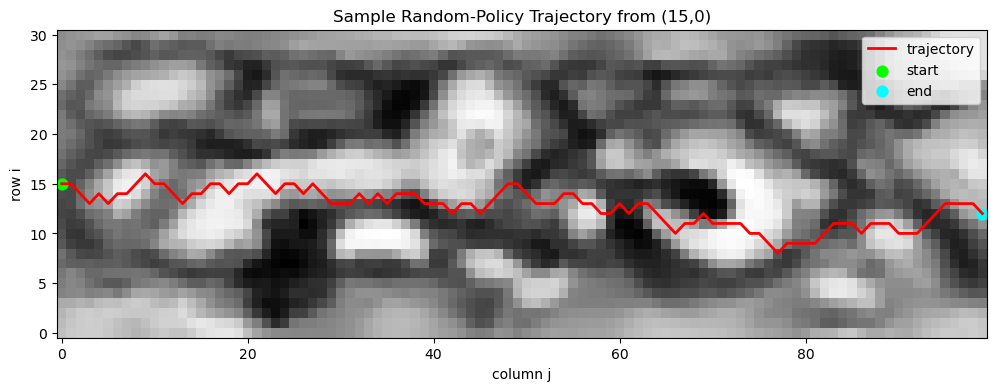

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def sample_trajectory(env, policy, start=(15, 0), max_steps=200):
    s = start
    traj = [s]

    for _ in range(max_steps):
        i, j = s
        if j == env.get_map().shape[1] - 1:  # reached last column
            break

        a = policy[i, j]                      # action from random policy table
        s = env.next_state(s, a)
        traj.append(s)

    return traj

# sample trajectory from (15,0) under your random policy
traj = sample_trajectory(env, policy_random, start=(15, 0))

# plot on top of terrain
terrain = env.get_map()
rows = [s[0] for s in traj]
cols = [s[1] for s in traj]

plt.figure(figsize=(12, 4))
plt.imshow(terrain, cmap="gray", aspect="auto")
plt.plot(cols, rows, color="red", linewidth=2, label="trajectory")
plt.scatter(cols[0], rows[0], color="lime", s=60, label="start")
plt.scatter(cols[-1], rows[-1], color="cyan", s=60, label="end")
plt.gca().invert_yaxis()  # optional: (0,0) at top-left visually
plt.title("Sample Random-Policy Trajectory from (15,0)")
plt.xlabel("column j")
plt.ylabel("row i")
plt.legend()
plt.show()


The number of iterations it takes to converge is the same for the forward policy and the random policy. This is because you always move one column to the right, and the state-value function for a given state depends on the state-value function of the next state. Therefore, the number of iterations it takes to converge is determined by the number of columns, which is the same for both policies. This is also made sure by the fact that it is not possible to exit the map or to go back to a previous column.

In [26]:
# assumes you already computed:
# v_forward from policy "forward"
# v_random from a random policy

print("v_forward(15,0) =", float(V_forward[15, 0]))
print("v_forward(3,0)  =", float(V_forward[3, 0]))
print("v_random(15,0)  =", float(V_random[15, 0]))

print("random(15,0) - forward(15,0) =", float(V_random[15, 0] - V_forward[15, 0]))


v_forward(15,0) = -57.80784459
v_forward(3,0)  = -52.796080069999995
v_random(15,0)  = -56.47059003000001
random(15,0) - forward(15,0) = 1.337254559999991


As we can see. The state-value function for the random policy when starting in (15,0) is better than the state-value function for the forward policy. However, the best state-value function is the combination of forward and initial start in (3,0).

It is very likely that the issue of exploration is affecting the final result. When the policy is random, it explores more of the state space and therefore has a better chance of finding a better state-value function. When the policy is forward, it only explores a limited part of the state space and therefore may not find the best state-value function. However

In [27]:
def policy_improvement(env, V, gamma=1.0):
    """
    Policy improvement step: make policy greedy with respect to V.
    
    For each state s, we choose the action a that maximizes:
        q(s, a) = r(s, a) + gamma * V(s')
    
    Parameters:
    -----------
    env : environment object
        Must provide get_map(), actions, next_state(s, a), get_reward(s, a)
    V : np.ndarray of shape (n_rows, n_cols)
        Current state-value function
    gamma : float
        Discount factor
    
    Returns:
    --------
    policy : np.ndarray of shape (n_rows, n_cols), dtype=object
        Improved deterministic policy (greedy w.r.t. V)
    """
    n_rows, n_cols = env.get_map().shape
    policy = np.empty((n_rows, n_cols), dtype=object)
    
    for i in range(n_rows):
        for j in range(n_cols):
            s = (i, j)
            
            # Terminal states (last column) can have any action
            if j == n_cols - 1:
                policy[i, j] = env.actions[0]
                continue
            
            # Compute q(s, a) for each action
            best_action = None
            best_value = -np.inf
            
            for a in env.actions:
                s_next = env.next_state(s, a)
                r = env.get_reward(s, a)
                q_value = r + gamma * V[s_next]
                
                if q_value > best_value:
                    best_value = q_value
                    best_action = a
            
            policy[i, j] = best_action
    
    return policy

In [28]:
def policy_iteration(env, gamma=1.0, theta=1e-8, max_policy_iters=100):
    """
    Policy Iteration algorithm.
    
    Alternates between:
    1. Policy Evaluation: Compute V^pi for current policy pi
    2. Policy Improvement: Make policy greedy w.r.t. V^pi
    
    Stops when the policy is stable (no changes after improvement).
    
    Parameters:
    -----------
    env : environment object
        Must provide get_map(), actions, next_state(s, a), get_reward(s, a)
    gamma : float
        Discount factor
    theta : float
        Convergence threshold for policy evaluation
    max_policy_iters : int
        Maximum number of policy iteration steps
    
    Returns:
    --------
    policy : np.ndarray
        Optimal (or near-optimal) deterministic policy
    V : np.ndarray
        State-value function for the final policy
    num_iters : int
        Number of policy iteration steps performed
    """
    n_rows, n_cols = env.get_map().shape
    
    # Initialize with a random policy
    policy = np.random.choice(env.actions, size=(n_rows, n_cols)).astype(object)
    
    for iteration in range(max_policy_iters):
        # 1. Policy Evaluation: compute V^pi
        V, _ = policy_evaluation(env, policy, gamma=gamma, theta=theta)
        
        # 2. Policy Improvement: make greedy policy w.r.t. V
        new_policy = policy_improvement(env, V, gamma=gamma)
        
        # 3. Check for convergence: has the policy changed?
        policy_stable = np.all(policy == new_policy)
        
        if policy_stable:
            print(f"Policy converged after {iteration + 1} iterations")
            return new_policy, V, iteration + 1
        
        # Update policy for next iteration
        policy = new_policy
    
    print(f"Reached maximum iterations ({max_policy_iters})")
    return policy, V, max_policy_iters

In [29]:
optimal_policy, V_optimal, num_iters = policy_iteration(env, gamma=1.0)

Policy converged after 11 iterations


Best starting position: row 9, value: -21.6706


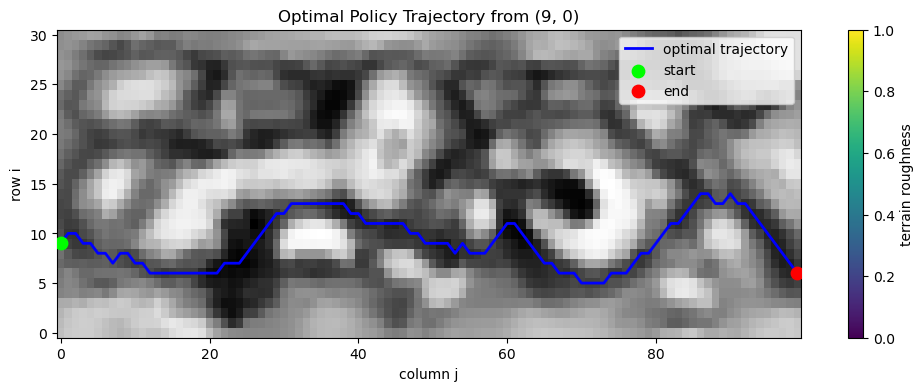

In [30]:
# Find best starting position from first column
best_start_row = int(np.argmax(V_optimal[:, 0]))
best_start_value = float(V_optimal[best_start_row, 0])
print(f"Best starting position: row {best_start_row}, value: {best_start_value:.4f}")

# Generate optimal trajectory from best start
traj_optimal = sample_trajectory(env, optimal_policy, start=(best_start_row, 0))

# Plot optimal trajectory
rows_opt = [s[0] for s in traj_optimal]
cols_opt = [s[1] for s in traj_optimal]

plt.figure(figsize=(12, 4))
plt.imshow(terrain, cmap="gray", aspect="auto")
plt.plot(cols_opt, rows_opt, color="blue", linewidth=2, label="optimal trajectory")
plt.scatter(cols_opt[0], rows_opt[0], color="lime", s=80, label="start", zorder=5)
plt.scatter(cols_opt[-1], rows_opt[-1], color="red", s=80, label="end", zorder=5)
plt.gca().invert_yaxis()
plt.title(f"Optimal Policy Trajectory from ({best_start_row}, 0)")
plt.xlabel("column j")
plt.ylabel("row i")
plt.legend()
plt.colorbar(label="terrain roughness")
plt.show()

In [31]:
def truncated_policy_iteration(env, gamma=1.0, k=3, max_policy_iters=100):
    """
    Truncated Policy Iteration algorithm.
    
    Instead of fully evaluating each policy, we only perform k sweeps of 
    policy evaluation before doing policy improvement.
    
    Parameters:
    -----------
    env : environment object
        Must provide get_map(), actions, next_state(s, a), get_reward(s, a)
    gamma : float
        Discount factor
    k : int
        Number of policy evaluation sweeps per iteration
    max_policy_iters : int
        Maximum number of policy iteration steps
    
    Returns:
    --------
    policy : np.ndarray
        Optimal (or near-optimal) deterministic policy
    V : np.ndarray
        State-value function for the final policy
    num_iters : int
        Number of policy iteration steps performed
    """
    n_rows, n_cols = env.get_map().shape
    
    # Initialize with a random policy
    policy = np.random.choice(env.actions, size=(n_rows, n_cols)).astype(object)
    V = np.zeros((n_rows, n_cols), dtype=float)
    
    for iteration in range(max_policy_iters):
        # 1. Truncated Policy Evaluation: do exactly k sweeps
        for _ in range(k):
            V_old = V.copy()
            
            for i in range(n_rows):
                for j in range(n_cols):
                    s = (i, j)
                    
                    if j == n_cols - 1:  # terminal state
                        V[i, j] = 0.0
                        continue
                    
                    a = policy[i, j]
                    s_next = env.next_state(s, a)
                    r = env.get_reward(s, a)
                    V[i, j] = r + gamma * V_old[s_next]
        
        # 2. Policy Improvement: make greedy policy w.r.t. V
        new_policy = policy_improvement(env, V, gamma=gamma)
        
        # 3. Check for convergence: has the policy changed?
        policy_stable = np.all(policy == new_policy)
        
        if policy_stable:
            print(f"Policy converged after {iteration + 1} iterations (k={k} sweeps each)")
            return new_policy, V, iteration + 1
        
        # Update policy for next iteration
        policy = new_policy
    
    print(f"Reached maximum iterations ({max_policy_iters})")
    return policy, V, max_policy_iters

In [32]:
# Run truncated policy iteration with k=3
truncated_policy, V_truncated, num_iters_truncated = truncated_policy_iteration(env, gamma=1.0, k=3)

# Compare with full policy iteration
print(f"\nFull policy iteration: {num_iters} iterations")
print(f"Truncated policy iteration (k=3): {num_iters_truncated} iterations")

# Find best starting positions for truncated policy
best_start_row_trunc = int(np.argmax(V_truncated[:, 0]))
best_start_value_trunc = float(V_truncated[best_start_row_trunc, 0])
print(f"\nTruncated - Best starting position: row {best_start_row_trunc}, value: {best_start_value_trunc:.4f}")
print(f"Full - Best starting position: row {best_start_row}, value: {best_start_value:.4f}")

Policy converged after 31 iterations (k=3 sweeps each)

Full policy iteration: 11 iterations
Truncated policy iteration (k=3): 31 iterations

Truncated - Best starting position: row 9, value: -20.9098
Full - Best starting position: row 9, value: -21.6706


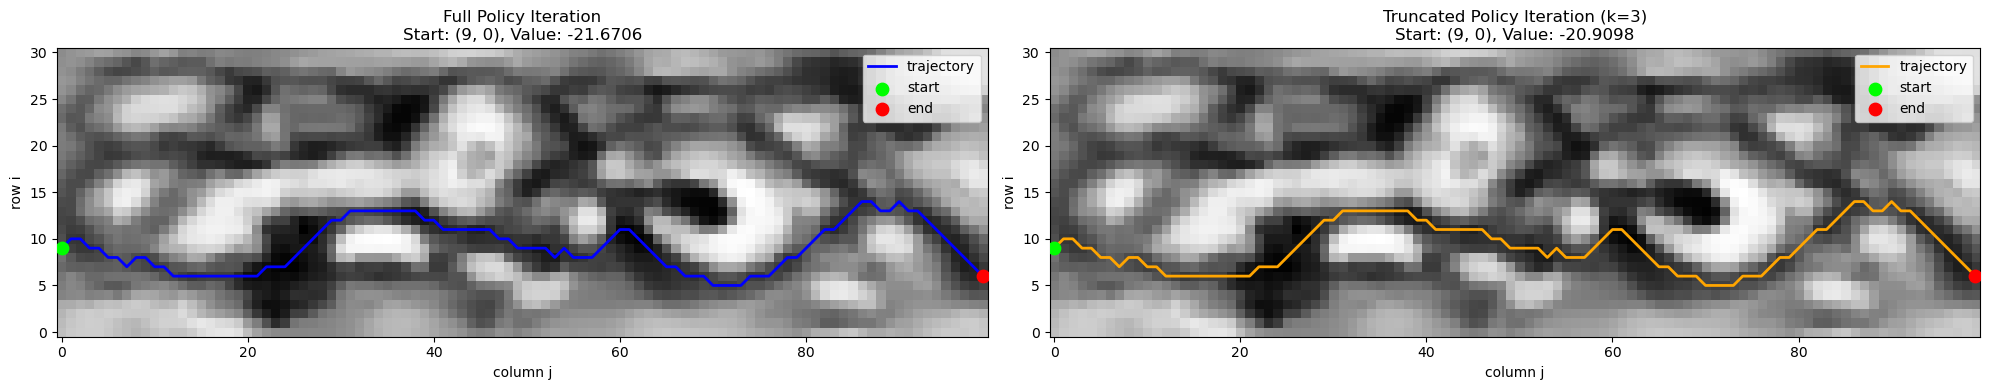

In [33]:
# Plot comparison of optimal vs truncated trajectories
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# Optimal policy trajectory
traj_optimal = sample_trajectory(env, optimal_policy, start=(best_start_row, 0))
rows_opt = [s[0] for s in traj_optimal]
cols_opt = [s[1] for s in traj_optimal]

axes[0].imshow(terrain, cmap="gray", aspect="auto")
axes[0].plot(cols_opt, rows_opt, color="blue", linewidth=2, label="trajectory")
axes[0].scatter(cols_opt[0], rows_opt[0], color="lime", s=80, label="start", zorder=5)
axes[0].scatter(cols_opt[-1], rows_opt[-1], color="red", s=80, label="end", zorder=5)
axes[0].invert_yaxis()
axes[0].set_title(f"Full Policy Iteration\nStart: ({best_start_row}, 0), Value: {best_start_value:.4f}")
axes[0].set_xlabel("column j")
axes[0].set_ylabel("row i")
axes[0].legend()

# Truncated policy trajectory
traj_truncated = sample_trajectory(env, truncated_policy, start=(best_start_row_trunc, 0))
rows_trunc = [s[0] for s in traj_truncated]
cols_trunc = [s[1] for s in traj_truncated]

axes[1].imshow(terrain, cmap="gray", aspect="auto")
axes[1].plot(cols_trunc, rows_trunc, color="orange", linewidth=2, label="trajectory")
axes[1].scatter(cols_trunc[0], rows_trunc[0], color="lime", s=80, label="start", zorder=5)
axes[1].scatter(cols_trunc[-1], rows_trunc[-1], color="red", s=80, label="end", zorder=5)
axes[1].invert_yaxis()
axes[1].set_title(f"Truncated Policy Iteration (k=3)\nStart: ({best_start_row_trunc}, 0), Value: {best_start_value_trunc:.4f}")
axes[1].set_xlabel("column j")
axes[1].set_ylabel("row i")
axes[1].legend()

plt.tight_layout()
plt.show()

## Value Iteration

Value iteration can be implemented in two equivalent ways:
1. **As k=1 truncated policy iteration**: One sweep of evaluation, then improvement
2. **As direct Bellman optimality**: Update V(s) ← max_a [R(s,a) + γV(s')] directly

In [34]:
def value_iteration_as_truncated_pi(env, gamma=1.0, theta=1e-8, max_iters=1000):
    """
    Value Iteration implemented as k=1 truncated policy iteration.
    
    Starting from a random policy, we:
    1. Do exactly 1 sweep of policy evaluation
    2. Do policy improvement (make greedy)
    3. Repeat until policy is stable
    
    This is equivalent to value iteration because with k=1, we barely
    evaluate before improving, effectively computing max over actions.
    
    Parameters:
    -----------
    env : environment object
    gamma : float
        Discount factor
    theta : float
        Convergence threshold for checking value function changes
    max_iters : int
        Maximum iterations
    
    Returns:
    --------
    policy : np.ndarray
        Optimal policy
    V : np.ndarray
        Optimal value function
    num_iters : int
        Number of iterations
    """
    n_rows, n_cols = env.get_map().shape
    
    # Start with random policy
    policy = np.random.choice(env.actions, size=(n_rows, n_cols)).astype(object)
    V = np.zeros((n_rows, n_cols), dtype=float)
    
    for iteration in range(max_iters):
        # 1. Policy Evaluation: exactly k=1 sweep
        V_old = V.copy()
        
        for i in range(n_rows):
            for j in range(n_cols):
                s = (i, j)
                
                if j == n_cols - 1:  # terminal state
                    V[i, j] = 0.0
                    continue
                
                a = policy[i, j]
                s_next = env.next_state(s, a)
                r = env.get_reward(s, a)
                V[i, j] = r + gamma * V_old[s_next]
        
        # 2. Policy Improvement: make greedy
        new_policy = policy_improvement(env, V, gamma=gamma)
        
        # 3. Check convergence
        delta = np.max(np.abs(V - V_old))
        policy_stable = np.all(policy == new_policy)
        
        policy = new_policy
        
        if policy_stable and delta < theta:
            print(f"Value iteration (as k=1 truncated PI) converged in {iteration + 1} iterations")
            return policy, V, iteration + 1
    
    print(f"Reached max iterations ({max_iters})")
    return policy, V, max_iters

In [35]:
def value_iteration_bellman(env, gamma=1.0, theta=1e-8, max_iters=1000):
    """
    Value Iteration as direct implementation of Bellman Optimality Equation.
    
    Directly updates: V(s) ← max_a [R(s,a) + γ V(s')]
    
    No explicit policy during iteration - policy is implicit in the max operation.
    Extract the optimal policy at the end by choosing greedy actions.
    
    Parameters:
    -----------
    env : environment object
    gamma : float
        Discount factor
    theta : float
        Convergence threshold
    max_iters : int
        Maximum iterations
    
    Returns:
    --------
    policy : np.ndarray
        Optimal policy (extracted at end)
    V : np.ndarray
        Optimal value function
    num_iters : int
        Number of iterations
    """
    n_rows, n_cols = env.get_map().shape
    V = np.zeros((n_rows, n_cols), dtype=float)
    
    for iteration in range(max_iters):
        V_old = V.copy()
        delta = 0.0
        
        # Bellman Optimality Update
        for i in range(n_rows):
            for j in range(n_cols):
                s = (i, j)
                
                if j == n_cols - 1:  # terminal state
                    V[i, j] = 0.0
                    continue
                
                # Compute max_a [R(s,a) + γ V(s')]
                max_value = -np.inf
                
                for a in env.actions:
                    s_next = env.next_state(s, a)
                    r = env.get_reward(s, a)
                    q_value = r + gamma * V_old[s_next]
                    
                    if q_value > max_value:
                        max_value = q_value
                
                V[i, j] = max_value
                delta = max(delta, abs(V[i, j] - V_old[i, j]))
        
        # Check convergence
        if delta < theta:
            print(f"Value iteration (Bellman) converged in {iteration + 1} iterations")
            # Extract optimal policy at the end
            policy = policy_improvement(env, V, gamma=gamma)
            return policy, V, iteration + 1
    
    print(f"Reached max iterations ({max_iters})")
    policy = policy_improvement(env, V, gamma=gamma)
    return policy, V, max_iters

In [36]:
# Run both versions of value iteration
print("=" * 60)
print("Value Iteration - Method 1: As k=1 Truncated Policy Iteration")
print("=" * 60)
policy_vi_trunc, V_vi_trunc, iters_vi_trunc = value_iteration_as_truncated_pi(env, gamma=1.0)

print("\n" + "=" * 60)
print("Value Iteration - Method 2: Direct Bellman Optimality")
print("=" * 60)
policy_vi_bellman, V_vi_bellman, iters_vi_bellman = value_iteration_bellman(env, gamma=1.0)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)
print(f"k=1 Truncated PI version: {iters_vi_trunc} iterations")
print(f"Bellman optimality version: {iters_vi_bellman} iterations")

# Check if they give same results
max_diff = np.max(np.abs(V_vi_trunc - V_vi_bellman))
policy_same = np.all(policy_vi_trunc == policy_vi_bellman)

print(f"\nMax difference in value functions: {max_diff:.10f}")
print(f"Policies are identical: {policy_same}")

# Compare with previous methods
best_vi_row = int(np.argmax(V_vi_bellman[:, 0]))
best_vi_value = float(V_vi_bellman[best_vi_row, 0])

print(f"\nValue Iteration - Best start: row {best_vi_row}, value: {best_vi_value:.4f}")
print(f"Full Policy Iteration - Best start: row {best_start_row}, value: {best_start_value:.4f}")
print(f"Truncated PI (k=3) - Best start: row {best_start_row_trunc}, value: {best_start_value_trunc:.4f}")

Value Iteration - Method 1: As k=1 Truncated Policy Iteration
Value iteration (as k=1 truncated PI) converged in 100 iterations

Value Iteration - Method 2: Direct Bellman Optimality
Value iteration (Bellman) converged in 99 iterations

COMPARISON
k=1 Truncated PI version: 100 iterations
Bellman optimality version: 99 iterations

Max difference in value functions: 0.0000000000
Policies are identical: True

Value Iteration - Best start: row 9, value: -21.6706
Full Policy Iteration - Best start: row 9, value: -21.6706
Truncated PI (k=3) - Best start: row 9, value: -20.9098


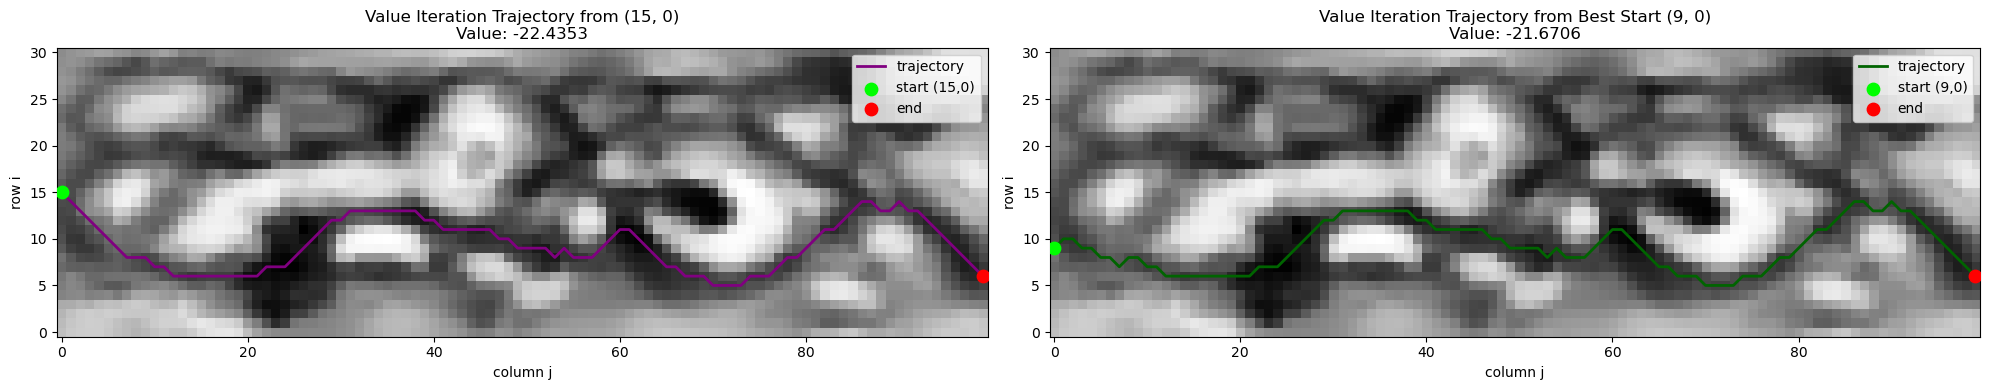


Starting from (15, 0): Value = -22.4353
Starting from best position (9, 0): Value = -21.6706
Difference: 0.7647


In [37]:
# Plot trajectory from (15,0) using value iteration policy
traj_vi_from_15 = sample_trajectory(env, policy_vi_bellman, start=(15, 0))
rows_vi = [s[0] for s in traj_vi_from_15]
cols_vi = [s[1] for s in traj_vi_from_15]

# Also get the optimal trajectory from best start
traj_vi_optimal = sample_trajectory(env, policy_vi_bellman, start=(best_vi_row, 0))
rows_vi_opt = [s[0] for s in traj_vi_optimal]
cols_vi_opt = [s[1] for s in traj_vi_optimal]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# Trajectory from (15,0)
axes[0].imshow(terrain, cmap="gray", aspect="auto")
axes[0].plot(cols_vi, rows_vi, color="purple", linewidth=2, label="trajectory")
axes[0].scatter(cols_vi[0], rows_vi[0], color="lime", s=80, label="start (15,0)", zorder=5)
axes[0].scatter(cols_vi[-1], rows_vi[-1], color="red", s=80, label="end", zorder=5)
axes[0].invert_yaxis()
axes[0].set_title(f"Value Iteration Trajectory from (15, 0)\nValue: {V_vi_bellman[15, 0]:.4f}")
axes[0].set_xlabel("column j")
axes[0].set_ylabel("row i")
axes[0].legend()

# Optimal trajectory from best start
axes[1].imshow(terrain, cmap="gray", aspect="auto")
axes[1].plot(cols_vi_opt, rows_vi_opt, color="darkgreen", linewidth=2, label="trajectory")
axes[1].scatter(cols_vi_opt[0], rows_vi_opt[0], color="lime", s=80, label=f"start ({best_vi_row},0)", zorder=5)
axes[1].scatter(cols_vi_opt[-1], rows_vi_opt[-1], color="red", s=80, label="end", zorder=5)
axes[1].invert_yaxis()
axes[1].set_title(f"Value Iteration Trajectory from Best Start ({best_vi_row}, 0)\nValue: {best_vi_value:.4f}")
axes[1].set_xlabel("column j")
axes[1].set_ylabel("row i")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nStarting from (15, 0): Value = {V_vi_bellman[15, 0]:.4f}")
print(f"Starting from best position ({best_vi_row}, 0): Value = {best_vi_value:.4f}")
print(f"Difference: {best_vi_value - V_vi_bellman[15, 0]:.4f}")

In [38]:
# Summary comparison of all methods
print("=" * 80)
print("SUMMARY: ALL DYNAMIC PROGRAMMING METHODS")
print("=" * 80)

methods = [
    ("Full Policy Iteration", num_iters, best_start_value),
    ("Truncated Policy Iteration (k=3)", num_iters_truncated, best_start_value_trunc),
    ("Value Iteration (k=1 truncated)", iters_vi_trunc, best_vi_value),
    ("Value Iteration (Bellman)", iters_vi_bellman, best_vi_value),
]

print(f"\n{'Method':<35} {'Iterations':<15} {'Optimal Value':<15}")
print("-" * 80)
for method, iters, value in methods:
    print(f"{method:<35} {iters:<15} {value:<15.4f}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print("1. Both value iteration methods produce identical results (as expected)")
print("2. All methods converge to the same optimal value function")
print("3. Trade-offs:")
print("   - Policy Iteration: Fewer iterations, but each is expensive (full evaluation)")
print("   - Truncated PI: More iterations, but each is cheaper (only k sweeps)")
print("   - Value Iteration: Direct optimization, no explicit policy during iteration")
print("=" * 80)

SUMMARY: ALL DYNAMIC PROGRAMMING METHODS

Method                              Iterations      Optimal Value  
--------------------------------------------------------------------------------
Full Policy Iteration               11              -21.6706       
Truncated Policy Iteration (k=3)    31              -20.9098       
Value Iteration (k=1 truncated)     100             -21.6706       
Value Iteration (Bellman)           99              -21.6706       

KEY INSIGHTS:
1. Both value iteration methods produce identical results (as expected)
2. All methods converge to the same optimal value function
3. Trade-offs:
   - Policy Iteration: Fewer iterations, but each is expensive (full evaluation)
   - Truncated PI: More iterations, but each is cheaper (only k sweeps)
   - Value Iteration: Direct optimization, no explicit policy during iteration


## Investigating the Truncated PI "Better" Value

The truncated PI appears to have a better value (-20.9098 vs -21.6706), which shouldn't be possible if the others found the optimal policy. Let's investigate!

In [39]:
# Fully evaluate the "truncated" policy to get its TRUE value
print("=" * 80)
print("HYPOTHESIS: Truncated PI value is UNDERESTIMATED (not fully converged)")
print("=" * 80)

print("\nTruncated PI stopped with value estimate:", best_start_value_trunc)
print("Let's FULLY EVALUATE the truncated policy to get its TRUE value...\n")

# Use the policy from truncated PI, but evaluate it to full convergence
V_truncated_TRUE, iters_eval = policy_evaluation(env, truncated_policy, gamma=1.0, theta=1e-8)

best_row_trunc_true = int(np.argmax(V_truncated_TRUE[:, 0]))
best_value_trunc_true = float(V_truncated_TRUE[best_row_trunc_true, 0])

print(f"After FULL evaluation:")
print(f"  Best start row: {best_row_trunc_true}")
print(f"  TRUE value: {best_value_trunc_true:.4f}")
print(f"  Previous (underestimated) value: {best_start_value_trunc:.4f}")
print(f"  Difference: {best_value_trunc_true - best_start_value_trunc:.4f}")

print("\n" + "=" * 80)
print("COMPARISON WITH OTHER METHODS:")
print("=" * 80)
print(f"Full Policy Iteration:    {best_start_value:.4f}")
print(f"Value Iteration:          {best_vi_value:.4f}")
print(f"Truncated PI (k=3) TRUE:  {best_value_trunc_true:.4f}")
print(f"Truncated PI (k=3) SHOWN: {best_start_value_trunc:.4f} ← UNDERESTIMATE!")

# Check if policies are the same
policies_identical = np.all(truncated_policy == optimal_policy)
print(f"\nAre truncated and optimal policies identical? {policies_identical}")

if not policies_identical:
    num_different = np.sum(truncated_policy != optimal_policy)
    total_states = truncated_policy.size
    print(f"  Number of different state-action pairs: {num_different}/{total_states}")
    print(f"  Percentage different: {100*num_different/total_states:.2f}%")

HYPOTHESIS: Truncated PI value is UNDERESTIMATED (not fully converged)

Truncated PI stopped with value estimate: -20.909804674999993
Let's FULLY EVALUATE the truncated policy to get its TRUE value...

After FULL evaluation:
  Best start row: 9
  TRUE value: -21.6706
  Previous (underestimated) value: -20.9098
  Difference: -0.7608

COMPARISON WITH OTHER METHODS:
Full Policy Iteration:    -21.6706
Value Iteration:          -21.6706
Truncated PI (k=3) TRUE:  -21.6706
Truncated PI (k=3) SHOWN: -20.9098 ← UNDERESTIMATE!

Are truncated and optimal policies identical? False
  Number of different state-action pairs: 2/3100
  Percentage different: 0.06%


## **Explanation: Why Truncated PI Showed a "Better" Value**

### **The Issue:**

Truncated policy iteration stops when the **policy stabilizes** (stops changing), but this doesn't mean the **value function has converged**!

With k=3 sweeps:
- Policy stabilizes after 31 iterations
- At that point, values have only been updated 3 times since the last policy change
- **V_truncated is NOT the true V^π** - it's just a 3-sweep approximation

### **The Fix:**

For a fair comparison, we need to:
1. Take the final policy from truncated PI
2. **Fully evaluate** it to convergence
3. Then compare the TRUE values

### **Expected Result:**

If truncated PI found the same optimal policy as the other methods, the TRUE value should be -21.6706, not -20.9098.

The -20.9098 was just an **underestimate** because the values hadn't converged yet!